# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Sandi Suryo Nugroho | 5054251020 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
https://www.kaggle.com/datasets/abbas829/bankruptcy

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

sns.set_style("whitegrid")


In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data,
# statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")
df.columns = df.columns.str.strip()

target_col = "Bankrupt?"

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data tiap kolom:")
print(df.dtypes.value_counts())

print("\nStatistik deskriptif (5 kolom pertama sebagai contoh):")
display(df.describe().iloc[:, :5])

print("\nJumlah missing value (total di seluruh dataset):", df.isnull().sum().sum())

df.head()


Jumlah baris dan kolom: (6819, 96)

Tipe data tiap kolom:
float64    93
int64       3
Name: count, dtype: int64

Statistik deskriptif (5 kolom pertama sebagai contoh):


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948
std,0.176710,0.060686,0.065620,0.061595,0.016934
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445
50%,0.000000,0.502706,0.559802,0.552278,0.605997
75%,0.000000,0.535563,0.589157,0.584105,0.613914
max,1.000000,1.000000,1.000000,1.000000,1.000000



Jumlah missing value (total di seluruh dataset): 0


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


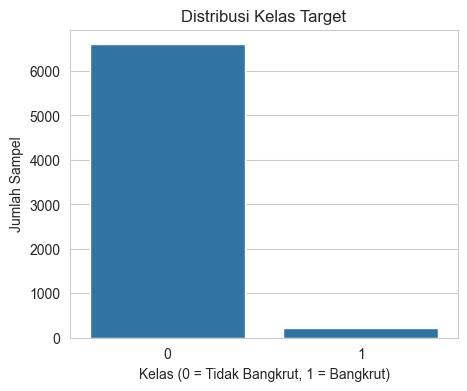

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Proporsi (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(5, 4))
order = df[target_col].value_counts().index
sns.countplot(x=target_col, data=df, order=order)
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas (0 = Tidak Bangkrut, 1 = Bangkrut)")
plt.ylabel("Jumlah Sampel")
plt.show()

counts = df[target_col].value_counts()
props = df[target_col].value_counts(normalize=True) * 100
print(counts)
print("\nProporsi (%):")
print(props.round(2))


Dataset ini SANGAT imbalanced, kelas bangkrut (1) hanya sekitar 3% dari total data.

Ini penting diingat saat evaluasi nanti: Accuracy saja bisa menyesatkan karena model

yang selalu menebak 'tidak bangkrut' pun sudah bisa dapat accuracy ~97%.

6 fitur dengan korelasi tertinggi terhadap target:
Net Income to Total Assets                                 0.315457
ROA(A) before interest and % after tax                     0.282941
ROA(B) before interest and depreciation after tax          0.273051
ROA(C) before interest and depreciation before interest    0.260807
Net worth/Assets                                           0.250161
Debt ratio %                                               0.250161
Name: Bankrupt?, dtype: float64


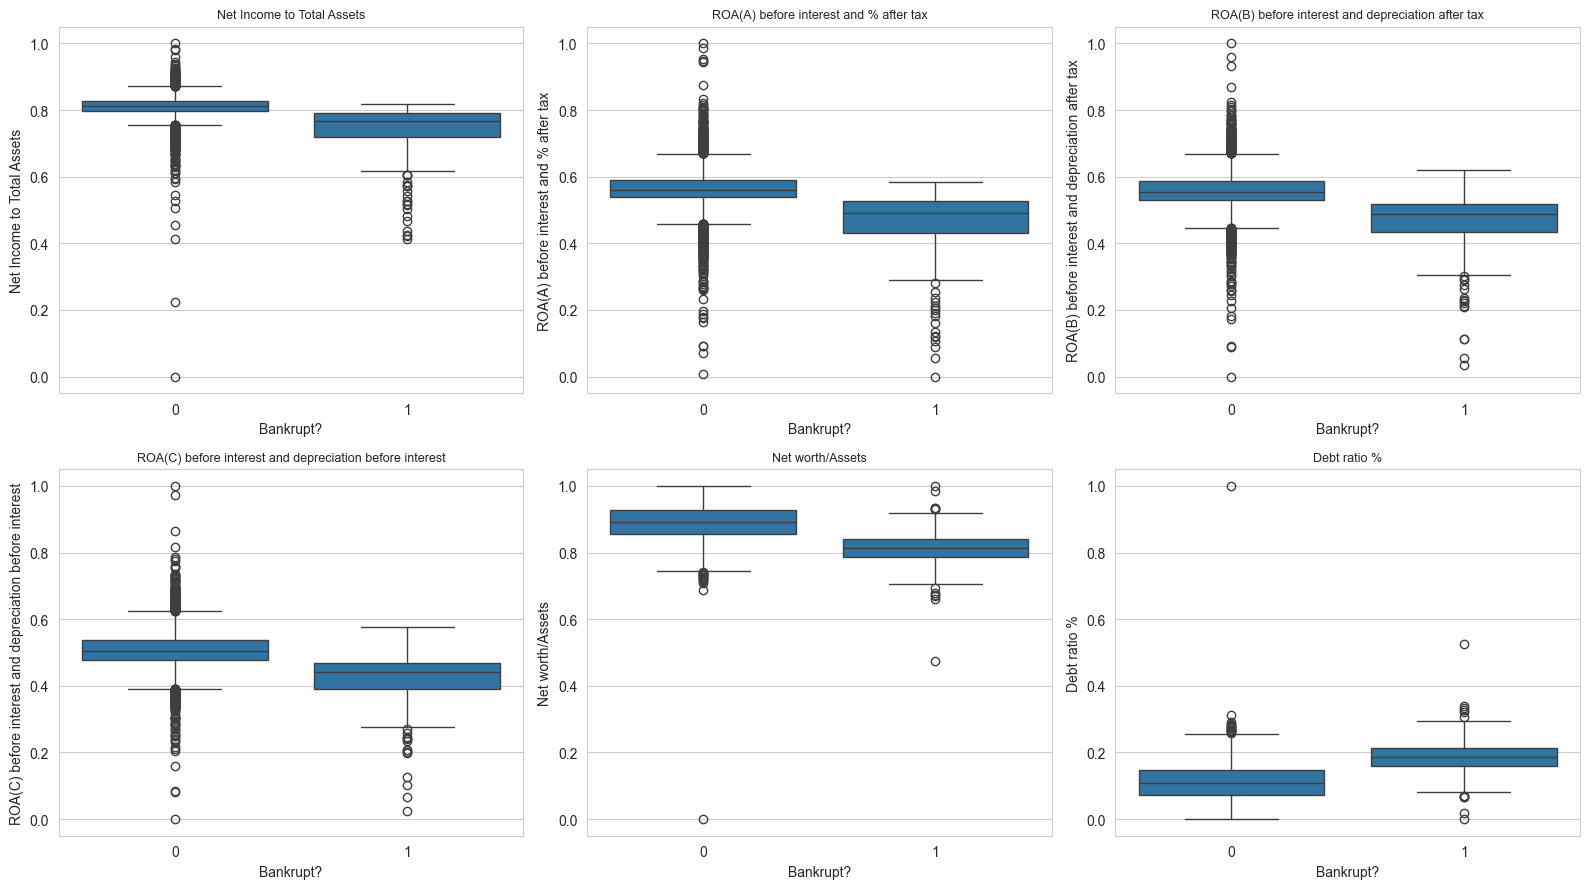

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot),
# dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

feature_cols = [c for c in df.columns if c != target_col]
constant_cols = [c for c in feature_cols if df[c].nunique() == 1]
corr_candidates = [c for c in feature_cols if c not in constant_cols]

correlations = df[corr_candidates + [target_col]].corr()[target_col].drop(target_col)
correlations = correlations.abs().sort_values(ascending=False)
top_features = correlations.head(6).index.tolist()

print("6 fitur dengan korelasi tertinggi terhadap target:")
print(correlations.head(6))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

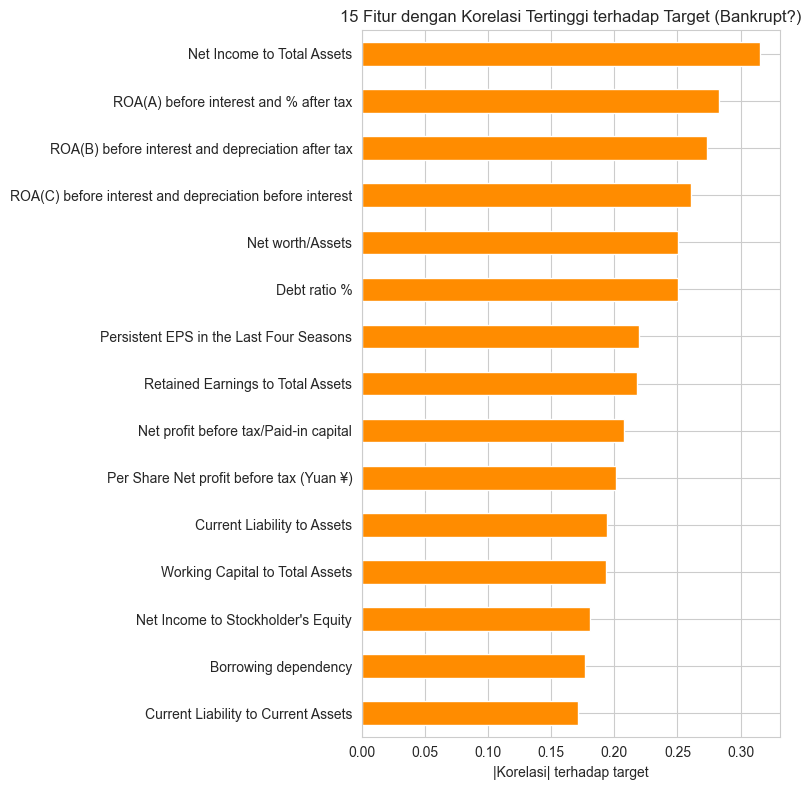

Kolom konstan yang dikeluarkan dari analisis korelasi: ['Net Income Flag']


In [5]:
# EDA tambahan: bar chart korelasi fitur-fitur teratas terhadap target.
plt.figure(figsize=(8, 8))
correlations.head(15).sort_values().plot(kind="barh", color="darkorange")
plt.title("15 Fitur dengan Korelasi Tertinggi terhadap Target (Bankrupt?)")
plt.xlabel("|Korelasi| terhadap target")
plt.tight_layout()
plt.show()

print(f"Kolom konstan yang dikeluarkan dari analisis korelasi: {constant_cols}")


# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Total missing value di seluruh dataset:", df.isnull().sum().sum())

assert df.isnull().sum().sum() == 0, "Ternyata ada missing value, tambahkan imputasi di sini."


Total missing value di seluruh dataset: 0


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot
# Encoding atau Ordinal Encoding).

print(df[target_col].dtype)
print(df[feature_cols].dtypes.unique())


int64
[dtype('float64') dtype('int64')]


Semua 95 fitur pada dataset ini sudah numerik, dan target

'Bankrupt?' juga sudah berbentuk numerik biner (0/1). Jadi TIDAK ada fitur
kategorikal yang perlu di-encode pada dataset ini.

In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran X_train:", X_train.shape, "| Ukuran X_test:", X_test.shape)
print("\nProporsi kelas di y_train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporsi kelas di y_test:")
print(y_test.value_counts(normalize=True).round(4))


Ukuran X_train: (5455, 95) | Ukuran X_test: (1364, 95)

Proporsi kelas di y_train:
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64

Proporsi kelas di y_test:
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [9]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini'
# menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)
y_pred_gini[:10]


array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy'
# menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar
# perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)
print(f"Akurasi test Gini    : {acc_gini:.4f}")
print(f"Akurasi test Entropy : {acc_entropy:.4f}")

best_criterion = "gini" if acc_gini >= acc_entropy else "entropy"
print(f"\nKriteria terbaik: {best_criterion}")


Akurasi test Gini    : 0.9611
Akurasi test Entropy : 0.9641

Kriteria terbaik: entropy


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [14]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depth_values = [1, 2, 3, 5, 10, None]
depth_models = {}

for depth in depth_values:
    model = DecisionTreeClassifier(criterion=best_criterion, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    depth_models[depth] = model

print(f"{len(depth_models)} model berhasil dilatih dengan criterion='{best_criterion}'.")


6 model berhasil dilatih dengan criterion='entropy'.


In [15]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
depth_results = []
for depth, model in depth_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    depth_results.append({"max_depth": depth, "train_acc": train_acc, "test_acc": test_acc})

df_depth = pd.DataFrame(depth_results)
df_depth


,max_depth,train_acc,test_acc
0,1.0,0.967736,0.967742
1,2.0,0.967736,0.967742
2,3.0,0.968286,0.969941
3,5.0,0.974335,0.966276
4,10.0,0.993034,0.963343
5,NaN,1.000000,0.964076


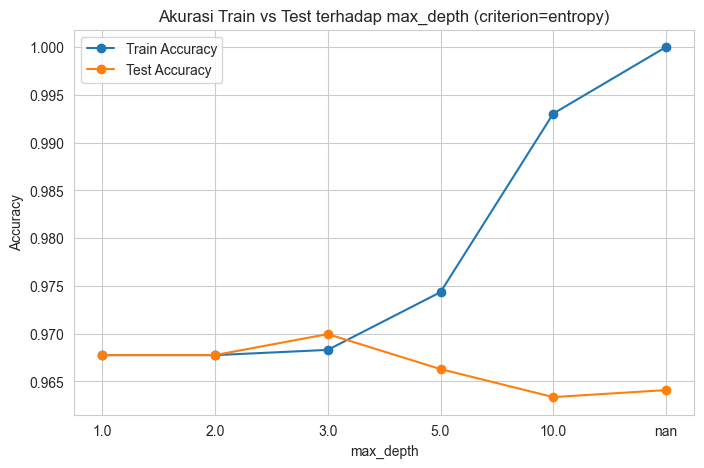

In [16]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
depth_labels = [str(d) for d in df_depth["max_depth"]]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, df_depth["train_acc"], marker="o", label="Train Accuracy")
plt.plot(depth_labels, df_depth["test_acc"], marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title(f"Akurasi Train vs Test terhadap max_depth (criterion={best_criterion})")
plt.legend()
plt.grid(True)
plt.show()


# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model
# Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }

metrics_gini = get_metrics(y_test, y_pred_gini, "Gini")
metrics_entropy = get_metrics(y_test, y_pred_entropy, "Entropy")

df_metrics = pd.DataFrame([metrics_gini, metrics_entropy]).set_index("Model")
df_metrics.round(4)


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Gini,0.9611,0.4000,0.4091,0.4045
Entropy,0.9641,0.4359,0.3864,0.4096


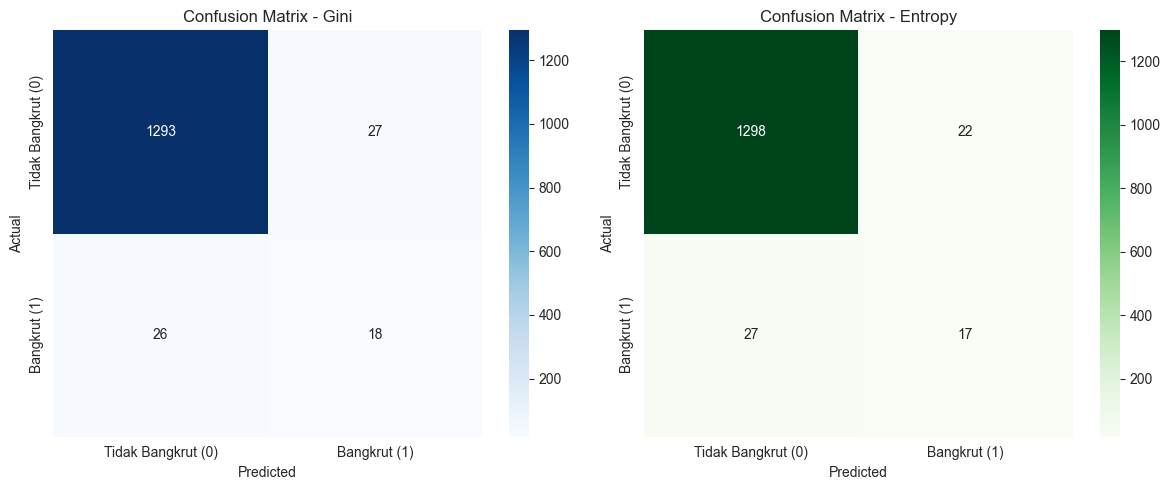

In [18]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
labels = ["Tidak Bangkrut (0)", "Bangkrut (1)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gini = confusion_matrix(y_test, y_pred_gini)
sns.heatmap(cm_gini, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix - Gini")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_entropy = confusion_matrix(y_test, y_pred_entropy)
sns.heatmap(cm_entropy, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix - Entropy")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


Model dengan performa terbaik (F1-Score tertinggi): Decision Tree - Entropy


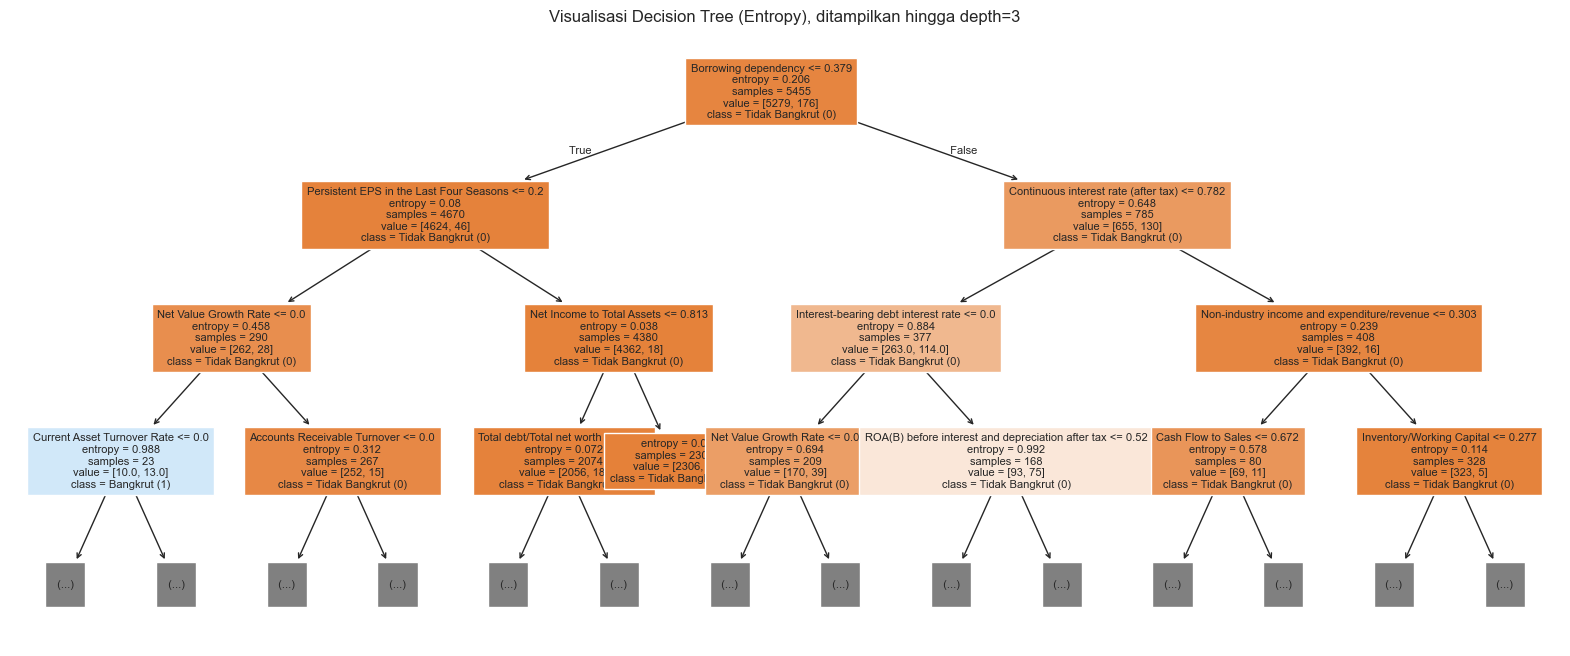

In [19]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan
# performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree)
# agar tetap mudah dibaca.
best_model = dt_gini if metrics_gini["F1-Score"] >= metrics_entropy["F1-Score"] else dt_entropy
best_model_name = "Gini" if best_model is dt_gini else "Entropy"
print(f"Model dengan performa terbaik (F1-Score tertinggi): Decision Tree - {best_model_name}")

plt.figure(figsize=(20, 8))
plot_tree(
    best_model,
    feature_names=feature_cols,
    class_names=labels,
    filled=True,
    max_depth=3,
    fontsize=8,
)
plt.title(f"Visualisasi Decision Tree ({best_model_name}), ditampilkan hingga depth=3")
plt.show()


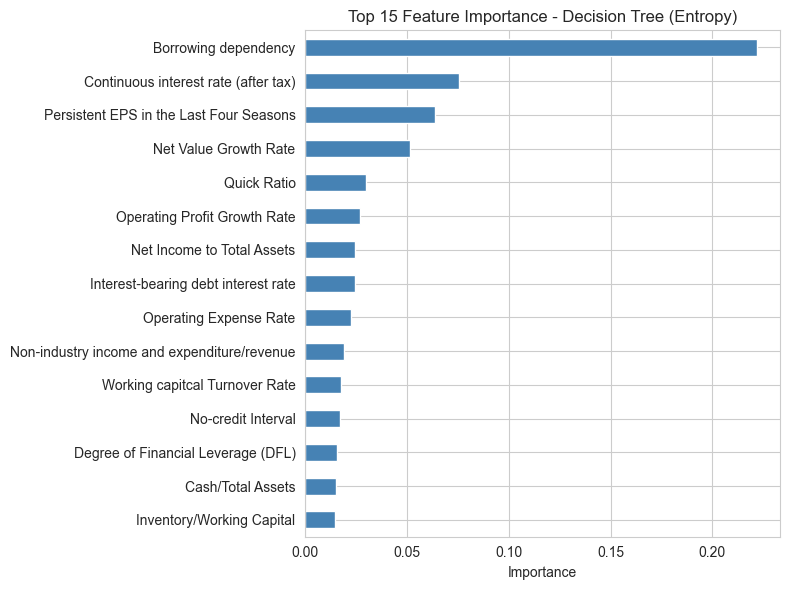

Borrowing dependency                           0.222147
Continuous interest rate (after tax)           0.075791
Persistent EPS in the Last Four Seasons        0.063519
Net Value Growth Rate                          0.051659
Quick Ratio                                    0.029765
Operating Profit Growth Rate                   0.026979
Net Income to Total Assets                     0.024663
Interest-bearing debt interest rate            0.024218
Operating Expense Rate                         0.022477
Non-industry income and expenditure/revenue    0.018859
Working capitcal Turnover Rate                 0.017671
No-credit Interval                             0.016993
Degree of Financial Leverage (DFL)             0.015759
Cash/Total Assets                              0.015094
Inventory/Working Capital                      0.014529
dtype: float64

In [20]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
top_importances = importances.sort_values(ascending=False).head(15).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
top_importances.plot(kind="barh", color="steelblue")
plt.title(f"Top 15 Feature Importance - Decision Tree ({best_model_name})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False).head(15)


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

---

- **Gini vs Entropy**

Dari tabel metrik, performanya nyaris identik:
| Metrik | Gini | Entropy |
|---|---|---|
| Accuracy | 96.11% | 96.41% |
| Precision | 40.00% | 43.59% |
| Recall | 40.91% | 38.64% |
| F1-Score | 40.45% | 40.96% |

beda cuma 1 sampel di confusion matrix (18 vs 17 dari 44 kasus bangkrut yang tertangkap). Wajar, karena Gini dan Entropy sama-sama mengukur impurity node dengan formula yang berkorelasi tinggi, jadi cenderung memilih split fitur yang sama, di sini sama-sama split pertama di `Borrowing dependency`.

- **Eksperimen max_depth**

`max_depth` 1–3: train dan test accuracy nyaris sama (~0.968), test bahkan sempat jadi titik tertinggi di depth=3 (~0.970). Model masih *underfit*, kapasitasnya belum cukup buat menangkap pola data.

Mulai `max_depth=5`: train naik ke 0.974 sementara test **turun** ke 0.966, di sinilah titik overfitting mulai muncul (gap mulai melebar).

`max_depth=10` dan tanpa batas: train terus naik sampai 1.000, tapi test malah di titik terendah (~0.964–0.966). Ciri overfitting: kurva train naik terus, kurva test stagnan/turun.

**Kesimpulan**: `max_depth=3` adalah titik paling optimal. akurasi test tertinggi dengan gap train-test paling kecil.

- **Feature Importance**

`Borrowing dependency` paling dominan (≈0.22, jauh di atas fitur lain), diikuti `Continuous interest rate (after tax)` (≈0.075) dan `Persistent EPS in the Last Four Seasons` (≈0.06). Konsisten dengan root split pohon. Masuk akal secara finansial: makin besar ketergantungan perusahaan pada utang, makin besar beban bunga dan risiko gagal bayar, sehingga jadi petunjuk kuat risiko bangkrut.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

---
Decision Tree dengan kriteria Entropy dan Gini menghasilkan performa yang setara (Accuracy ~96%, F1-Score ~41%).

`max_depth=3` memberikan generalisasi terbaik, di luar itu model mulai overfitting. Ditandai train accuracy yang terus naik sampai 100% sementara test accuracy stagnan/menurun. 

Fitur `Borrowing dependency` adalah prediktor terkuat risiko kebangkrutan.

Namun perlu dicatat: Recall untuk kelas bangkrut hanya ~39–41%. Dari ~44 perusahaan yang benar-benar bangkrut, model cuma menangkap 17–18. Untuk kasus prediksi kebangkrutan, melewatkan kasus positif (false negative) jauh lebih mahal daripada Accuracy tinggi yang menyesatkan akibat data imbalanced.

**Saran untuk eksperimen selanjutnya:**
- Coba `class_weight='balanced'` atau teknik oversampling (SMOTE) untuk menaikkan Recall kelas bangkrut.
- Coba cost-complexity pruning (`ccp_alpha`) sebagai alternatif pembatasan `max_depth`.
- Bandingkan dengan Random Forest, yang biasanya lebih tahan overfitting dan lebih baik menangani data imbalanced dibanding single Decision Tree.